Saved figure.
Migrated points (original idx): [22, 71, 122, 194, 237]
  point 237: cluster 0 -> 2
  point 22: cluster 1 -> 0
  point 122: cluster 1 -> 0
  point 194: cluster 2 -> 1
  point 71: cluster 0 -> 2


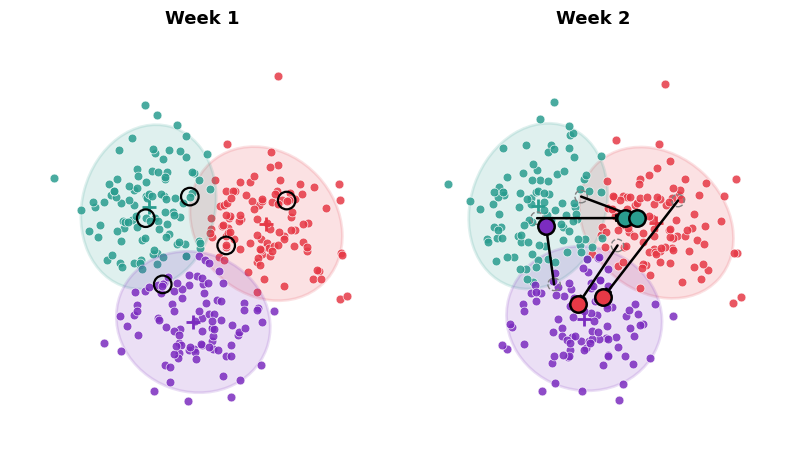

In [9]:
"""
Toy demo: clustering, then re-clustering after a few points drift
into a different cluster. Ellipses show each cluster's spread;
arrows highlight the handful of points that actually migrated.
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from scipy.optimize import linear_sum_assignment

rng = np.random.default_rng(42)

# ---------------------------------------------------------------
# 1. Generate initial points: 3 closer-together, overlapping blobs
# ---------------------------------------------------------------
N_POINTS = 300
N_CLUSTERS = 3

centers = np.array([
    [-2.0,  1.5],
    [ 1.5,  1.0],
    [-0.5, -2.0],
])

X1, _ = make_blobs(
    n_samples=N_POINTS,
    centers=centers,
    n_features=2,
    cluster_std=1.3,
    random_state=42,
)

# ---------------------------------------------------------------
# 2. Cluster the initial points (KMeans)
# ---------------------------------------------------------------
km1 = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
labels1 = km1.fit_predict(X1)

# ---------------------------------------------------------------
# 3. Drift the points slightly (most points barely move — small
#    jitter only). Then hand-pick a SMALL number of points to
#    move strongly into a different cluster.
# ---------------------------------------------------------------
X2 = X1.copy()

# small global jitter so the second plot isn't pixel-identical
X2 += rng.normal(scale=0.25, size=X2.shape)

N_MIGRANTS = 5
migrant_idx = rng.choice(N_POINTS, size=N_MIGRANTS, replace=False)

rough_centroids = np.array(
    [X1[labels1 == c].mean(axis=0) for c in range(N_CLUSTERS)]
)

migrant_targets = {}  # idx -> target cluster
for idx in migrant_idx:
    origin = labels1[idx]
    target = rng.choice([c for c in range(N_CLUSTERS) if c != origin])
    migrant_targets[idx] = target
    X2[idx] = (
        0.15 * X1[idx]
        + 0.85 * rough_centroids[target]
        + rng.normal(scale=0.3, size=2)
    )

# ---------------------------------------------------------------
# 4. Re-cluster the drifted points
# ---------------------------------------------------------------
km2 = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
labels2_raw = km2.fit_predict(X2)

# ---------------------------------------------------------------
# 5. Align labels2 to labels1 via Hungarian algorithm (max overlap)
# ---------------------------------------------------------------
overlap = np.zeros((N_CLUSTERS, N_CLUSTERS), dtype=int)
for i in range(N_CLUSTERS):
    for j in range(N_CLUSTERS):
        overlap[i, j] = np.sum((labels1 == i) & (labels2_raw == j))

row_ind, col_ind = linear_sum_assignment(-overlap)
remap = {j: i for i, j in zip(row_ind, col_ind)}
labels2 = np.array([remap[j] for j in labels2_raw])

moved_mask = labels1 != labels2

# ---------------------------------------------------------------
# Helper: draw a covariance ellipse for a cluster's points
# ---------------------------------------------------------------
def draw_cluster_ellipse(ax, points, color, n_std=2.2, **kwargs):
    if len(points) < 2:
        return
    mean = points.mean(axis=0)
    cov = np.cov(points, rowvar=False)
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = eigvals.argsort()[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]
    angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
    width, height = 2 * n_std * np.sqrt(eigvals)
    ellipse = Ellipse(
        xy=mean, width=width, height=height, angle=angle,
        facecolor=color, edgecolor=color, alpha=0.15,
        linewidth=2.0, **kwargs,
    )
    ax.add_patch(ellipse)
    ax.plot(*mean, marker="+", color=color, markersize=10, mew=2)


# ---------------------------------------------------------------
# 6. Plot
# ---------------------------------------------------------------
colors = ["#e63946", "#2a9d8f", "#7b2cbf"]  # red, green, purple
cluster_names = ["Cluster 1", "Cluster 2", "Cluster 3"]

fig, axes = plt.subplots(1, 2, figsize=(10, 6.5))
plt.subplots_adjust(wspace=0.02)

# --- Panel 1: initial clustering ---
ax = axes[0]
for c in range(N_CLUSTERS):
    mask = labels1 == c
    draw_cluster_ellipse(ax, X1[mask], colors[c])
    ax.scatter(
        X1[mask, 0], X1[mask, 1],
        c=colors[c], s=40, alpha=0.85,
        edgecolor="white", linewidth=0.5,
    )

# mark the points that will later migrate, so you can compare panels
ax.scatter(
    X1[migrant_idx, 0], X1[migrant_idx, 1],
    facecolor="none", edgecolor="black", s=160,
    linewidth=1.6, zorder=5,
)

ax.set_title("Week 1", fontsize=13, fontweight="bold")
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

# --- Panel 2: new positions + cluster ellipses + migration arrows ---
ax = axes[1]
for c in range(N_CLUSTERS):
    mask = labels2 == c
    draw_cluster_ellipse(ax, X2[mask], colors[c])

# all non-migrant points, coloured by ORIGINAL cluster
non_migrant_mask = np.ones(N_POINTS, dtype=bool)
non_migrant_mask[migrant_idx] = False
for c in range(N_CLUSTERS):
    mask = (labels1 == c) & non_migrant_mask
    ax.scatter(
        X2[mask, 0], X2[mask, 1],
        c=colors[c], s=40, alpha=0.85,
        edgecolor="white", linewidth=0.5,
    )

# migrant points + arrows from old -> new position
for idx in migrant_idx:
    origin = labels1[idx]
    ax.annotate(
        "",
        xy=X2[idx], xytext=X1[idx],
        arrowprops=dict(
            arrowstyle="-|>", color="black",
            lw=1.8, shrinkA=0, shrinkB=0,
        ),
        zorder=6,
    )
    # faint marker at the OLD position for reference
    ax.scatter(*X1[idx], facecolor="none", edgecolor="gray",
               s=80, linewidth=1.0, zorder=4, linestyle="--")
    # solid marker at the NEW position, coloured by ORIGIN cluster
    ax.scatter(*X2[idx], c=colors[origin], s=140,
               edgecolor="black", linewidth=1.8, zorder=7)

ax.set_title("Week 2", fontsize=13, fontweight="bold")
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

# match axis limits across both panels for fair visual comparison
all_x = np.concatenate([X1[:, 0], X2[:, 0]])
all_y = np.concatenate([X1[:, 1], X2[:, 1]])
pad = 1.5
xlim = (all_x.min() - pad, all_x.max() + pad)
ylim = (all_y.min() - pad, all_y.max() + pad)
for ax in axes:
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect("equal")

print("Saved figure.")
print(f"Migrated points (original idx): {sorted(migrant_idx.tolist())}")
for idx in migrant_idx:
    print(f"  point {idx}: cluster {labels1[idx]} -> {labels2[idx]}")